In [35]:
from processor.processor import Processor as processor
from extractor.alp_client_extractor import ALPClientExtractor
from database.adatabase import ADatabase
from xgboost import XGBRegressor
from statistics import mean
import math
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm
from dotenv import load_dotenv
load_dotenv()
import os
import warnings
warnings.simplefilter(action="ignore")

In [36]:
start = datetime.now() - timedelta(days=365.25*2)
end = datetime.now()

In [37]:
key = os.getenv("APCAKEY")
secret = os.getenv("APCASECRET")
alp_client = ALPClientExtractor(key,secret)
account = alp_client.account()
cash = float(account["cash"])
factors =  ["AMZN","GOOGL","AAPL","NVDA","TSLA","MSFT","META"]
market = ADatabase("market")
holding_period = 5
stoploss = 1
positions = 1
sec = ADatabase("sec")

In [38]:
def calculate_expected_return(row, factors):
    factor_loadings = [row[factor] * row[f"{factor}_beta"] for factor in factors]
    return np.mean(factor_loadings)

In [39]:
sp500 = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",attrs={"id":"constituents"})[0].rename(columns={"Symbol":"ticker"})
sp500

,ticker,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [40]:
## download factors
factor_dfs = []
market.connect()
for ticker in factors:
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","ticker","adjclose"]]
        ticker_prices["historical_return"] = ticker_prices["adjclose"].pct_change(holding_period) 
        factor_dfs.append(ticker_prices)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()
factor_df = pd.concat(factor_dfs).pivot_table(index="date",columns="ticker",values="historical_return").reset_index()
factor_df

ticker,date,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
0,2016-01-11 05:00:00+00:00,-0.064920,-0.030141,-0.034764,-0.046077,-0.045620,-0.083045,-0.069174
1,2016-01-12 05:00:00+00:00,-0.026869,-0.025245,-0.021271,-0.032707,-0.041235,-0.082452,-0.060403
2,2016-01-13 05:00:00+00:00,-0.032963,-0.080304,-0.052410,-0.073128,-0.044588,-0.072054,-0.085616
3,2016-01-14 05:00:00+00:00,0.031937,-0.024671,-0.012955,0.004596,0.018018,-0.053104,-0.043811
4,2016-01-15 05:00:00+00:00,0.001650,-0.060626,-0.028181,-0.024247,-0.025607,-0.085043,-0.028429
...,...,...,...,...,...,...,...,...
990,2019-12-16 05:00:00+00:00,0.048554,0.011203,0.013254,-0.016986,0.027550,0.061275,0.123233
991,2019-12-17 05:00:00+00:00,0.044398,0.029554,0.008937,-0.012346,0.023556,0.066729,0.086414
992,2019-12-18 05:00:00+00:00,0.033240,0.020128,0.005803,0.001187,0.017601,0.055944,0.114845
993,2019-12-19 05:00:00+00:00,0.031683,0.018064,0.005933,0.047319,0.016119,0.049750,0.123436


In [41]:
simulation = []
market.connect()
for ticker in tqdm(sp500["ticker"]):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices["ticker"] = ticker
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices = processor.merge(ticker_prices,factor_df.copy(),on="date")
        ticker_prices["historical_return"] = ticker_prices["adjclose"].pct_change(holding_period)
        for factor in factors:
            ticker_prices[f"{factor}_covariance"] = ticker_prices["historical_return"].rolling(100).cov(ticker_prices[factor])
            ticker_prices[f"{factor}_beta"] = ticker_prices[f"{factor}_covariance"] / ticker_prices[factor].rolling(100).var()
            ticker_prices[f"{factor}_loading"] = ticker_prices[factor] * ticker_prices[f"{factor}_beta"]
        ticker_prices.dropna(inplace=True)
        ticker_prices["average_return"] = ticker_prices["adjclose"].pct_change(holding_period).rolling(100).mean()
        ticker_prices["coev"] = ticker_prices["adjclose"].rolling(100).std() / ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["buy_date"] = ticker_prices["date"].shift(-1)
        ticker_prices["sell_date"] = ticker_prices["date"].shift(-holding_period)
        ticker_prices["buy_price"] = ticker_prices["adjclose"].shift(-1)
        ticker_prices["sell_price"] = ticker_prices["adjclose"].shift(-holding_period)
        ticker_prices["return"] = (ticker_prices["sell_price"] - ticker_prices["buy_price"]) / ticker_prices["buy_price"]
        ticker_prices["expected_return"] = ticker_prices.apply(lambda row: calculate_expected_return(row, factors), axis=1)
        simulation.append(ticker_prices)
    except Exception as e:
        print(ticker,str(e))
        continue
sim = pd.concat(simulation)

  3%|██▋                                                                                             | 14/503 [00:00<00:33, 14.43it/s]

ABNB attempt to get argmax of an empty sequence


 12%|███████████▊                                                                                    | 62/503 [00:04<00:27, 15.80it/s]

BBWI attempt to get argmax of an empty sequence


 18%|█████████████████▎                                                                              | 91/503 [00:05<00:25, 16.30it/s]

...

 95%|██████████████████████████████████████████████████████████████████████████████████████████     | 477/503 [00:31<00:01, 13.91it/s]

VTRS attempt to get argmax of an empty sequence


 97%|███████████████████████████████████████████████████████████████████████████████████████████▊   | 486/503 [00:32<00:01, 16.15it/s]

WBD attempt to get argmax of an empty sequence


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [00:33<00:00, 15.11it/s]


In [42]:
sim

,date,adjclose,ticker,year,quarter,month,week,weekday,AAPL,AMZN,...,META_beta,META_loading,average_return,coev,buy_date,sell_date,buy_price,sell_price,return,expected_return
104,2016-06-02 04:00:00+00:00,168.04,MMM,2016,2,6,22,3,-0.019269,0.027950,...,0.207603,0.001831,NaN,NaN,2016-06-03 04:00:00+00:00,2016-06-09 04:00:00+00:00,168.38,170.13,0.010393,0.000924
105,2016-06-03 04:00:00+00:00,168.38,MMM,2016,2,6,22,4,-0.024701,0.014825,...,0.200000,-0.001674,NaN,NaN,2016-06-06 04:00:00+00:00,2016-06-10 04:00:00+00:00,170.08,168.56,-0.008937,-0.000517
106,2016-06-06 04:00:00+00:00,170.08,MMM,2016,2,6,23,0,-0.017138,0.020500,...,0.192893,-0.000953,NaN,NaN,2016-06-07 04:00:00+00:00,2016-06-13 04:00:00+00:00,170.91,167.13,-0.022117,-0.001114
107,2016-06-07 04:00:00+00:00,170.91,MMM,2016,2,6,23,1,-0.008410,0.001384,...,0.181829,-0.001607,NaN,NaN,2016-06-08 04:00:00+00:00,2016-06-14 04:00:00+00:00,171.42,167.61,-0.022226,-0.001687
108,2016-06-08 04:00:00+00:00,171.42,MMM,2016,2,6,23,2,0.004874,0.010008,...,0.181172,-0.000595,NaN,NaN,2016-06-09 04:00:00+00:00,2016-06-15 04:00:00+00:00,170.13,167.80,-0.013695,-0.000963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2019-12-16 05:00:00+00:00,126.46,ZTS,2019,4,12,51,0,0.048554,0.011203,...,0.209887,-0.003565,0.004276,0.030454,2019-12-17 05:00:00+00:00,NaT,127.10,NaN,NaN,-0.000865
996,2019-12-17 05:00:00+00:00,127.10,ZTS,2019,4,12,51,1,0.044398,0.029554,...,0.204704,-0.002527,0.004539,0.029889,2019-12-18 05:00:00+00:00,NaT,126.99,NaN,NaN,0.000057
997,2019-12-18 05:00:00+00:00,126.99,ZTS,2019,4,12,51,2,0.033240,0.020128,...,0.204509,0.000243,0.004850,0.029355,2019-12-19 05:00:00+00:00,NaT,128.74,NaN,NaN,0.000082
998,2019-12-19 05:00:00+00:00,128.74,ZTS,2019,4,12,51,3,0.031683,0.018064,...,0.216358,0.010238,0.005217,0.029000,2019-12-20 05:00:00+00:00,NaT,132.68,NaN,NaN,0.001493


In [43]:
trades = sim[sim["weekday"]==4].copy()
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades.sort_values("date",inplace=True)
iteration_trades = trades.copy().sort_values("coev",ascending=False).groupby("date").nth([i for i in range(positions)]).reset_index()
iteration_trades.sort_values("date",inplace=True)
iteration_trades

,index,date,adjclose,ticker,year,quarter,month,week,weekday,AAPL,...,META_beta,META_loading,average_return,coev,buy_date,sell_date,buy_price,sell_price,return,expected_return
163,105,2016-06-03 04:00:00+00:00,168.38,MMM,2016,2,6,22,4,-0.024701,...,0.200000,-0.001674,NaN,NaN,2016-06-06 04:00:00+00:00,2016-06-10 04:00:00+00:00,170.08,168.56,-0.008937,-0.000517
164,110,2016-06-10 04:00:00+00:00,52.50,SNPS,2016,2,6,23,4,0.009395,...,0.184193,-0.002876,NaN,NaN,2016-06-13 04:00:00+00:00,2016-06-17 04:00:00+00:00,52.14,52.46,0.006137,-0.000955
165,115,2016-06-17 04:00:00+00:00,34.29,FE,2016,2,6,24,4,-0.035613,...,0.044842,-0.001384,NaN,NaN,2016-06-20 04:00:00+00:00,2016-06-24 04:00:00+00:00,33.74,32.88,-0.025489,-0.002798
166,120,2016-06-24 04:00:00+00:00,16.66,ANET,2016,2,6,25,4,-0.020143,...,0.517348,-0.004303,NaN,NaN,2016-06-27 04:00:00+00:00,2016-07-01 04:00:00+00:00,15.23,15.92,0.045305,-0.010544
167,125,2016-07-01 04:00:00+00:00,59.71,ES,2016,3,7,26,4,0.026552,...,0.220347,0.004148,NaN,NaN,2016-07-05 04:00:00+00:00,2016-07-11 04:00:00+00:00,60.25,59.33,-0.015270,0.001147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,980,2019-11-22 05:00:00+00:00,7.31,PCG,2019,4,11,47,4,-0.015051,...,0.591604,0.011280,-0.041716,0.400055,2019-11-25 05:00:00+00:00,2019-12-02 05:00:00+00:00,7.40,7.86,0.062162,0.006574
118,984,2019-11-29 05:00:00+00:00,7.46,PCG,2019,4,11,48,4,0.020000,...,0.698975,0.013102,-0.036664,0.388107,2019-12-02 05:00:00+00:00,2019-12-06 05:00:00+00:00,7.86,9.65,0.227735,0.008737
123,989,2019-12-06 05:00:00+00:00,9.65,PCG,2019,4,12,49,4,0.013022,...,0.833944,-0.002440,-0.018944,0.375511,2019-12-09 05:00:00+00:00,2019-12-13 05:00:00+00:00,11.18,11.24,0.005367,-0.001922
127,994,2019-12-13 05:00:00+00:00,11.24,PCG,2019,4,12,50,4,0.016401,...,0.862844,-0.029784,-0.002613,0.352525,2019-12-16 05:00:00+00:00,2019-12-20 05:00:00+00:00,9.67,10.99,0.136505,-0.020554


In [44]:
iteration_trades["return"] = iteration_trades["return"] * (1/positions)
iteration_trades["return"] = [max(float(-stoploss/positions),x) for x in iteration_trades["return"]]
portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio.iloc[:-1]
portfolio["year"] = [x.year for x in portfolio["date"]]
portfolio["return"] = portfolio["return"] + 1
portfolio["cumulative_return"] = portfolio["return"].cumprod()
portfolio

,date,return,year,cumulative_return
0,2016-06-03 04:00:00+00:00,0.991063,2016,0.991063
1,2016-06-10 04:00:00+00:00,1.006137,2016,0.997146
2,2016-06-17 04:00:00+00:00,0.974511,2016,0.971729
3,2016-06-24 04:00:00+00:00,1.045305,2016,1.015754
4,2016-07-01 04:00:00+00:00,0.984730,2016,1.000243
...,...,...,...,...
177,2019-11-15 05:00:00+00:00,1.031030,2019,4.929741
178,2019-11-22 05:00:00+00:00,1.062162,2019,5.236185
179,2019-11-29 05:00:00+00:00,1.227735,2019,6.428649
180,2019-12-06 05:00:00+00:00,1.005367,2019,6.463150


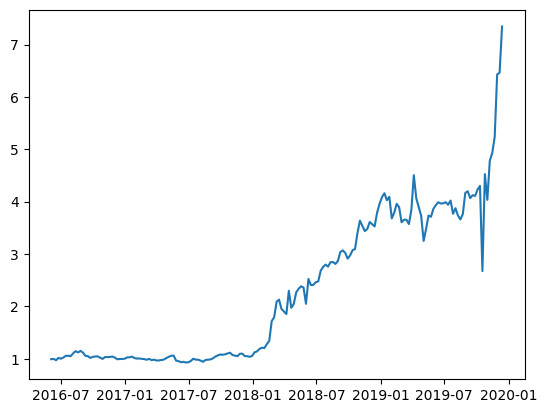

In [45]:
plt.plot(portfolio["date"].values,portfolio["cumulative_return"])

In [46]:
results = {}
results["number_of_trades"] = iteration_trades.index.size
results["standard_deviation"] = portfolio["cumulative_return"].std()
results["coefficient_of_variance"] = portfolio["cumulative_return"].std() / portfolio["cumulative_return"].mean()
results["sharpe"] = portfolio["cumulative_return"].iloc[-1] / portfolio["cumulative_return"].std()
results["return"] = portfolio["cumulative_return"].iloc[-1]
results = pd.DataFrame([results]).round(4).to_dict("records")[0]
results

{'number_of_trades': 183,
 'standard_deviation': 1.4126,
 'coefficient_of_variance': 0.6181,
 'sharpe': 5.1999,
 'return': 7.3454}

In [47]:
recommendations = iteration_trades[iteration_trades["date"]==iteration_trades["date"].max()].copy()
recommendations

,index,date,adjclose,ticker,year,quarter,month,week,weekday,AAPL,...,META_beta,META_loading,average_return,coev,buy_date,sell_date,buy_price,sell_price,return,expected_return
132,999,2019-12-20 05:00:00+00:00,10.99,PCG,2019,4,12,51,4,0.015555,...,0.811844,0.050983,-0.006632,0.321587,NaT,NaT,NaN,NaN,-1.0,-0.022425


In [48]:
# try:
#     positions = recommendations.index.size
#     notional = math.floor(float(cash/positions),2)
#     for row in recommendations.iterrows():
#         ticker = row[1]["ticker"]
#         print(alp_client.buy(ticker,notional))
# except Exception as e:
#     print(str(e))